# Vector DB 스키마와 Collection 설계

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import sys

os.environ['HF_HOME'] = '/content/drive/MyDrive/hf_cache'

!pip install -q  chromadb sentence-transformers pillow

from sentence_transformers import SentenceTransformer

_MODEL_CACHE = {}

def load_model(name="paraphrase-multilingual-MiniLM-L12-v2"):
    """같은 모델을 여러 섹션에서 재로딩하지 않도록 캐싱한다."""
    if name not in _MODEL_CACHE:
        _MODEL_CACHE[name] = SentenceTransformer(name)
    return _MODEL_CACHE[name]

import uuid
import chromadb

def new_client():
    """이전 섹션과 격리된 새 in-memory Chroma 클라이언트를 반환한다."""
    name = "sec_" + uuid.uuid4().hex[:8]
    base = chromadb.EphemeralClient()
    try:
        chromadb.AdminClient(base.get_settings()).create_database(name, "default_tenant")
        return chromadb.EphemeralClient(tenant="default_tenant", database=name)
    except Exception:
        for c in base.list_collections():
            base.delete_collection(c.name if hasattr(c, "name") else c)
        return base

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 27.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 40.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.6/204.6 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.5 MB/s eta 0:00:00
ERROR: pip's dependency reso

---

## Vector DB Schema 기본 구조

- 실습 내용
  - 문장 3개 → 임베딩 변환
  - 메타 데이터 붙여서 Collection 저장
  - 의미 검색 + 메타 필터 검색

In [2]:
import numpy as np
model = load_model("paraphrase-multilingual-MiniLM-L12-v2")
client = new_client()

Loading weights:   0%|          | 0/199 [00:02<?, ?it/s]

### 1. 스키마 3요소 준비
- ① 원천 데이터: 원본 텍스트
- ② 임베딩: 원천 데이터를 숫자 벡터로 변환
- ③ 메타 데이터: 검색·필터링용 부가 정보

In [3]:
docs = ["김치찌개는 신김치와 돼지고기를 넣고 끓인다",
        "된장찌개는 된장과 두부를 넣고 끓인다",
        "비빔밥은 나물과 고추장을 밥에 비벼 먹는다"]
vectors = model.encode(docs).tolist()
metas = [{"category": "찌개", "cook_time": 30},
         {"category": "찌개", "cook_time": 20},
         {"category": "밥", "cook_time": 15}]

print("벡터 차원:", len(vectors[0]))
print("첫 벡터 앞 5개:", vectors[0][:5])

벡터 차원: 384
첫 벡터 앞 5개: [-0.032218411564826965, 0.1933184117078781, 0.03667972981929779, 0.061331856995821, -0.08215490728616714]


### 2. Collection 생성 및 저장
- Collection = RDB의 Table과 유사한 개념
- id + 원천 데이터 + 벡터 + 메타 데이터를 한 번에 저장

In [4]:
col = client.create_collection("recipes", metadata={"hnsw:space": "cosine"})
col.add(ids=["r1", "r2", "r3"], documents=docs, embeddings=vectors, metadatas=metas)
print("저장 건수:", col.count())

저장 건수: 3


### 3. 검색
- 의미 검색: 질문을 벡터로 바꿔 가장 가까운 문서 탐색
- 메타 필터: category 조건으로 검색 범위 축소

In [5]:
q = model.encode(["돼지고기가 들어간 찌개"]).tolist()

print("[의미 검색]")
r = col.query(query_embeddings=q, n_results=2)
print(r["documents"], r["distances"])

print("\n[의미 검색 + 메타 필터 category=밥]")
r = col.query(query_embeddings=q, n_results=1, where={"category": "밥"})
print(r["documents"], r["metadatas"])

[의미 검색]
[['김치찌개는 신김치와 돼지고기를 넣고 끓인다', '된장찌개는 된장과 두부를 넣고 끓인다']] [[0.3017919659614563, 0.3875446319580078]]

[의미 검색 + 메타 필터 category=밥]
[['비빔밥은 나물과 고추장을 밥에 비벼 먹는다']] [[{'category': '밥', 'cook_time': 15}]]


---

## Collection Design 개요 및 단위

- 실습 내용
  - 하나의 DB 안에 여러 Collection 생성
  - Collection 목록 조회·삭제
  - RDB Table ↔ Collection 개념 비교

In [6]:
client = new_client()   # Database 역할 (논리적 그룹)

### 1. 여러 Collection 생성
- 유사한 데이터끼리 하나의 Collection
- 객체지향의 Class, RDB의 Table 도출 단위와 유사

In [7]:
recipes = client.create_collection("recipes")      # 요리 레시피
reviews = client.create_collection("reviews")      # 요리 후기
members = client.create_collection("members")      # 회원 선호

print([c.name for c in client.list_collections()])

['reviews', 'recipes', 'members']


### 2. Collection 관리 대상 3가지
- 임베딩 값(벡터), 문서(원천 데이터), 메타 데이터

In [8]:
recipes.add(
    ids=["r1"],
    embeddings=[[0.1, 0.9, 0.3, 0.2]],                  # 벡터
    documents=["김치찌개: 신김치와 돼지고기를 끓인다"],   # 원천 데이터
    metadatas=[{"category": "찌개", "level": "초급"}],    # 메타 데이터
)
recipes.get(ids=["r1"], include=["documents", "metadatas", "embeddings"])

{'ids': ['r1'],
 'embeddings': array([[0.1       , 0.89999998, 0.30000001, 0.2       ]]),
 'documents': ['김치찌개: 신김치와 돼지고기를 끓인다'],
 'uris': None,
 'included': ['documents', 'metadatas', 'embeddings'],
 'data': None,
 'metadatas': [{'level': '초급', 'category': '찌개'}]}

### 3. RDB Table과 비교
- RDB: Column 정의 → Row 저장
- Vector DB: 메타 필드 + 벡터 → Item 저장

In [9]:
compare = {
    "RDB":       {"그룹": "Database", "단위": "Table",      "행": "Row",  "속성": "Column"},
    "Vector DB": {"그룹": "Database", "단위": "Collection", "행": "Item", "속성": "Meta + Vector"},
}
for k, v in compare.items():
    print(k, v)

RDB {'그룹': 'Database', '단위': 'Table', '행': 'Row', '속성': 'Column'}
Vector DB {'그룹': 'Database', '단위': 'Collection', '행': 'Item', '속성': 'Meta + Vector'}


### 4. Collection 삭제·재조회
- 비정형 데이터도 논리 기준에 따라 분리/통합 가능

In [10]:
client.delete_collection("reviews")
print([c.name for c in client.list_collections()])

['recipes', 'members']


---

## 단일 Collection vs 멀티 Collection 설계

- 실습 내용
  - 단일 Collection: 전체 저장 + 메타 필터
  - 멀티 Collection: 종류별 분리 저장
  - 두 방식의 검색 코드 비교

In [11]:
import numpy as np
model = load_model("paraphrase-multilingual-MiniLM-L12-v2")
client = new_client()

In [12]:
data = [
    ("korean",  "김치찌개는 신김치와 돼지고기를 끓인다"),
    ("korean",  "비빔밥은 나물과 고추장을 밥에 비빈다"),
    ("western", "카르보나라는 베이컨과 계란으로 만든 파스타"),
    ("western", "마르게리타 피자는 토마토와 바질 토핑"),
    ("chinese", "짜장면은 춘장을 볶아 면에 비빈다"),
]
vecs = model.encode([d[1] for d in data]).tolist()

### 1. 단일 Collection 설계
- 모든 데이터를 한 곳에 저장
- 종류 구분은 메타 데이터로 처리

In [13]:
single = client.create_collection("recipes_all", metadata={"hnsw:space": "cosine"})
single.add(ids=[f"r{i}" for i in range(len(data))],
           documents=[d[1] for d in data], embeddings=vecs,
           metadatas=[{"cuisine": d[0]} for d in data])

q = model.encode(["면 요리"]).tolist()
print(single.query(query_embeddings=q, n_results=2)["documents"])
print(single.query(query_embeddings=q, n_results=1, where={"cuisine": "western"})["documents"])

[['카르보나라는 베이컨과 계란으로 만든 파스타', '짜장면은 춘장을 볶아 면에 비빈다']]
[['카르보나라는 베이컨과 계란으로 만든 파스타']]


### 2. 멀티 Collection 설계
- 종류별로 Collection 분리
- 검색 시 대상 Collection을 직접 선택

In [14]:
multi = {}
for i, (cuisine, text) in enumerate(data):
    if cuisine not in multi:
        multi[cuisine] = client.create_collection(f"recipes_{cuisine}", metadata={"hnsw:space": "cosine"})
    multi[cuisine].add(ids=[f"r{i}"], documents=[text], embeddings=[vecs[i]])

for name, col in multi.items():
    print(name, col.count(), "건")

print(multi["western"].query(query_embeddings=q, n_results=1)["documents"])

korean 2 건
western 2 건
chinese 1 건
[['카르보나라는 베이컨과 계란으로 만든 파스타']]


### 3. 설계 판단 함수
- 소규모: 단일 Collection 통합 관리
- 대규모: 병렬 처리·성능 최적화를 위해 분산

In [15]:
def choose_design(n_items, n_types):
    if n_items < 100_000:
        return "단일 Collection + 메타 필터"
    if n_types >= 3:
        return "멀티 Collection (종류별 분리)"
    return "단일 Collection (샤딩 검토)"

print(choose_design(5_000, 3))
print(choose_design(5_000_000, 3))

단일 Collection + 메타 필터
멀티 Collection (종류별 분리)


---

## 대용량 단일 Collection 관리의 장단점

- 실습 내용
  - 가짜 벡터 대량 생성
  - 단일 vs 분할 검색 시간 측정
  - 백업(저장) 시간 비교

In [16]:
import numpy as np, time
np.random.seed(0)
DIM = 128

### 1. 대용량 벡터 생성
- 실제 대신 난수 벡터 사용
- 단일: 200,000건 한 덩어리 / 분할: 4개 × 50,000건

In [17]:
single = np.random.rand(200_000, DIM).astype("float32")
parts = [single[i*50_000:(i+1)*50_000] for i in range(4)]   # 업무 유형별 분할 가정
query = np.random.rand(DIM).astype("float32")

### 2. 검색 시간 비교
- 단일: 전체 스캔
- 분할: 해당 업무 Collection 1개만 스캔

In [18]:
def search(vectors, q, k=5):
    sims = vectors @ q
    return np.argsort(-sims)[:k]

t = time.time(); search(single, query); print("단일 Collection 검색:", round(time.time()-t, 4), "초")
t = time.time(); search(parts[0], query); print("분할 Collection 검색:", round(time.time()-t, 4), "초")

단일 Collection 검색: 0.0506 초
분할 Collection 검색: 0.012 초


### 3. 백업·복구 시간 비교
- 단일: 전체를 한 번에 저장
- 분할: 변경된 부분만 저장 가능

In [19]:
t = time.time(); np.save("single.npy", single); print("단일 전체 백업:", round(time.time()-t, 4), "초")
t = time.time(); np.save("part0.npy", parts[0]); print("분할 1개 백업:", round(time.time()-t, 4), "초")

단일 전체 백업: 0.1539 초
분할 1개 백업: 0.0799 초


### 4. 인덱싱(정렬) 부담 비교
- 데이터 추가 시 인덱스 재구성 비용도 규모에 비례

In [20]:
t = time.time(); np.sort(single[:, 0]); print("단일 인덱싱:", round(time.time()-t, 4), "초")
t = time.time(); np.sort(parts[0][:, 0]); print("분할 인덱싱:", round(time.time()-t, 4), "초")

단일 인덱싱: 0.036 초
분할 인덱싱: 0.0071 초


---

## 이기종 데이터의 단일 Collection 통합 관리

- 실습 내용
  - CLIP 모델로 이미지·텍스트 임베딩
  - 같은 Collection에 이미지·텍스트 저장
  - 텍스트로 이미지 검색

In [21]:
from PIL import Image, ImageDraw

clip = load_model("clip-ViT-B-32")   # 이미지·텍스트 동일 공간
client = new_client()

modules.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/1.91k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.03k [00:00<?, ?B/s]

0_CLIPModel/model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

...

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/604 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/961k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

### 1. 샘플 이미지 생성
- 빨간 원, 파란 사각형, 초록 삼각형 3장

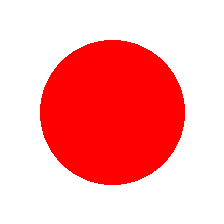

In [22]:
def make_image(shape, color):
    img = Image.new("RGB", (224, 224), "white")
    d = ImageDraw.Draw(img)
    if shape == "circle":   d.ellipse((40, 40, 184, 184), fill=color)
    if shape == "square":   d.rectangle((40, 40, 184, 184), fill=color)
    if shape == "triangle": d.polygon([(112, 30), (30, 190), (194, 190)], fill=color)
    return img

images = {"red_circle": make_image("circle", "red"),
          "blue_square": make_image("square", "blue"),
          "green_triangle": make_image("triangle", "green")}
images["red_circle"]

### 2. 이미지 + 텍스트를 하나의 Collection에 저장
- 데이터 유형은 메타 데이터(type)로 구분

In [23]:
col = client.create_collection("multimodal", metadata={"hnsw:space": "cosine"})

img_vecs = clip.encode(list(images.values())).tolist()
col.add(ids=list(images.keys()), embeddings=img_vecs,
        documents=list(images.keys()), metadatas=[{"type": "image"}] * 3)

texts = ["a photo of a red apple", "a photo of the blue sky", "a green leaf"]
txt_vecs = clip.encode(texts).tolist()
col.add(ids=["t1", "t2", "t3"], embeddings=txt_vecs,
        documents=texts, metadatas=[{"type": "text"}] * 3)

print("저장 건수:", col.count())

저장 건수: 6


### 3. 텍스트로 이미지·텍스트 통합 검색

In [42]:
for q in ["a red circle", "something blue", "a green triangle"]:
    r = col.query(query_embeddings=clip.encode([q]).tolist(), n_results=3)
    print(q, "→", list(zip(r["documents"][0], [m["type"] for m in r["metadatas"][0]])))

# for q in ["a red circle", "something blue", "a green triangle"]:
#     qv = clip.encode([q]).tolist()
#     img = col.query(query_embeddings=qv, n_results=1, where={"type": "image"})
#     txt = col.query(query_embeddings=qv, n_results=1, where={"type": "text"})
#     print(f"{q:18s} → 이미지: {img['documents'][0][0]:15s} / 텍스트: {txt['documents'][0][0]}")

a red circle       → 이미지: red_circle      / 텍스트: a photo of a red apple
something blue     → 이미지: blue_square     / 텍스트: a photo of the blue sky
a green triangle   → 이미지: green_triangle  / 텍스트: a green leaf


### 4. 벡터 크기 비교
- 멀티모달 모델은 벡터가 커져 저장·계산 비용 증가

In [25]:
text_model = load_model("paraphrase-multilingual-MiniLM-L12-v2")
print("텍스트 전용 모델 차원:", text_model.get_sentence_embedding_dimension())
print("CLIP 멀티모달 차원  :", clip.get_sentence_embedding_dimension())

텍스트 전용 모델 차원: 384
CLIP 멀티모달 차원  : 512


/tmp/ipykernel_609/2199096832.py:2: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print("텍스트 전용 모델 차원:", text_model.get_sentence_embedding_dimension())
/tmp/ipykernel_609/2199096832.py:3: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print("CLIP 멀티모달 차원  :", clip.get_sentence_embedding_dimension())


---

## Collection 설계 단위 결정 5대 기준

- 실습 내용
  - 데이터 프로파일 입력
  - 기준별 판단 함수 작성
  - 분할 권고안 출력

In [26]:
profile = {
    "size_gb": 350,                      # ① 데이터 크기
    "access": ["최근 레시피", "한식만"],   # ② 접근 패턴
    "lifecycle_days": 90,                # ③ 생명주기 (오래된 데이터 삭제 주기)
    "attributes": ["한식", "양식", "중식"],  # ④ 속성
    "automation": "낮음",                 # ⑤ 운영 자동화 수준
}

### 1. 기준별 판단 함수
- 각 기준이 '분할 필요'면 1점

In [27]:
def check_size(p):      return p["size_gb"] > 100
def check_access(p):    return len(p["access"]) >= 2
def check_lifecycle(p): return p["lifecycle_days"] <= 180
def check_attr(p):      return len(p["attributes"]) >= 3
def check_ops(p):       return p["automation"] != "낮음"   # 자동화 낮으면 분할 자제

checks = {"① 크기·스케일링": check_size, "② 접근 패턴": check_access,
          "③ 생명주기": check_lifecycle, "④ 속성": check_attr, "⑤ 운영 용이성": check_ops}

### 2. 점검표 실행

In [28]:
score = 0
for name, fn in checks.items():
    result = fn(profile)
    score += result
    print(f"{name:12s} → {'분할 유리' if result else '통합 유리'}")
print("\n분할 점수:", score, "/ 5")

① 크기·스케일링    → 분할 유리
② 접근 패턴      → 분할 유리
③ 생명주기       → 분할 유리
④ 속성         → 분할 유리
⑤ 운영 용이성     → 통합 유리

분할 점수: 4 / 5


### 3. 권고안 도출
- 점수 3 이상: 멀티 Collection
- 자동화 낮음: 분할 개수 상한 제한

In [29]:
def recommend(p, score):
    if score < 3:
        return "단일 Collection"
    max_cols = 3 if p["automation"] == "낮음" else 10
    return f"멀티 Collection (최대 {max_cols}개 권장)"

print(recommend(profile, score))

멀티 Collection (최대 3개 권장)


### 4. 다른 프로파일로 재시도

In [30]:
small = {"size_gb": 5, "access": ["전체"], "lifecycle_days": 3650, "attributes": ["한식"], "automation": "낮음"}
s = sum(fn(small) for fn in checks.values())
print("소규모 프로파일 점수:", s, "→", recommend(small, s))

소규모 프로파일 점수: 0 → 단일 Collection


---

## Collection 설계 사례 — 레시피 데이터

- 실습 내용
  - 레시피 샘플 데이터 생성
  - 3가지 설계 방법론 함수 작성
  - 방법별 Collection 분포 비교

In [31]:
from collections import Counter
recipes = [
    {"id": 1, "date": "20240530", "cuisine": "korean",  "title": "김치찌개"},
    {"id": 2, "date": "20240530", "cuisine": "western", "title": "카르보나라"},
    {"id": 3, "date": "20240601", "cuisine": "korean",  "title": "비빔밥"},
    {"id": 4, "date": "20240615", "cuisine": "chinese", "title": "짜장면"},
    {"id": 5, "date": "20240702", "cuisine": "korean",  "title": "된장찌개"},
    {"id": 6, "date": "20240702", "cuisine": "western", "title": "마르게리타"},
]

### 1. 데이터 특성 분석
- 날짜별 등록량, 종류별 분포 확인

In [32]:
print("날짜별:", Counter(r["date"] for r in recipes))
print("종류별:", Counter(r["cuisine"] for r in recipes))

날짜별: Counter({'20240530': 2, '20240702': 2, '20240601': 1, '20240615': 1})
종류별: Counter({'korean': 3, 'western': 2, 'chinese': 1})


### 2. 3가지 설계 방법론
- 날짜 기준: recipe_20240530
- 주제 기준: recipe_korean
- 혼합 기준: recipe_202405_korean

In [33]:
def by_date(r):  return f"recipe_{r['date']}"
def by_topic(r): return f"recipe_{r['cuisine']}"
def by_mixed(r): return f"recipe_{r['date'][:6]}_{r['cuisine']}"

for name, fn in [("날짜 기준", by_date), ("주제 기준", by_topic), ("혼합 기준", by_mixed)]:
    dist = Counter(fn(r) for r in recipes)
    print(f"[{name}] Collection {len(dist)}개")
    for k, v in sorted(dist.items()):
        print("  ", k, v, "건")

[날짜 기준] Collection 4개
   recipe_20240530 2 건
   recipe_20240601 1 건
   recipe_20240615 1 건
   recipe_20240702 2 건
[주제 기준] Collection 3개
   recipe_chinese 1 건
   recipe_korean 3 건
   recipe_western 2 건
[혼합 기준] Collection 6개
   recipe_202405_korean 1 건
   recipe_202405_western 1 건
   recipe_202406_chinese 1 건
   recipe_202406_korean 1 건
   recipe_202407_korean 1 건
   recipe_202407_western 1 건


### 3. 접근 패턴별 검색 범위 비교
- 질문: '2024년 7월 한식 레시피' → 방식별로 읽어야 할 Collection
- 날짜 기준: 7월 전체(모든 종류) / 주제 기준: 한식 전체(모든 기간) / 혼합: 7월 한식만

In [34]:
def target_collections(fn, month="202407", cuisine="korean"):
    cols = sorted({fn(r) for r in recipes})
    return [c for c in cols if month in c and cuisine in c] or  [c for c in cols if month in c] or            [c for c in cols if cuisine in c]

for name, fn in [("날짜", by_date), ("주제", by_topic), ("혼합", by_mixed)]:
    print(name, "→ 읽어야 할 Collection:", target_collections(fn))

날짜 → 읽어야 할 Collection: ['recipe_20240702']
주제 → 읽어야 할 Collection: ['recipe_korean']
혼합 → 읽어야 할 Collection: ['recipe_202407_korean']


---

## 여러 Collection에 걸친 유사도 검색

- 실습 내용
  - Collection A·B 생성 후 교차 검색
  - 다른 모델 벡터 비교 시 오류 확인

In [35]:
def cos(a, b):
    a, b = np.array(a), np.array(b)
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))

In [36]:
import numpy as np
model = load_model("paraphrase-multilingual-MiniLM-L12-v2")
client = new_client()

### 1. Collection A(레시피), B(후기) 생성
- 같은 모델로 벡터화

In [37]:
col_a = client.create_collection("recipes", metadata={"hnsw:space": "cosine"})
col_b = client.create_collection("reviews", metadata={"hnsw:space": "cosine"})

a_docs = ["김치찌개는 신김치와 돼지고기를 끓인다", "비빔밥은 나물을 고추장에 비빈다"]
b_docs = ["김치찌개가 얼큰하고 맛있었어요", "파스타가 느끼해서 별로였어요"]
col_a.add(ids=["a1", "a2"], documents=a_docs, embeddings=model.encode(a_docs).tolist())
col_b.add(ids=["b1", "b2"], documents=b_docs, embeddings=model.encode(b_docs).tolist())

### 2. 교차 검색
- Collection 배열을 순회하며 결과 합치기
- 거리 기준으로 정렬

In [38]:
def cross_search(query, collections, k=3):
    q = model.encode([query]).tolist()
    results = []
    for col in collections:
        r = col.query(query_embeddings=q, n_results=2)
        for doc, dist in zip(r["documents"][0], r["distances"][0]):
            results.append((col.name, doc, round(dist, 3)))
    return sorted(results, key=lambda x: x[2])[:k]

for row in cross_search("얼큰한 찌개", [col_a, col_b]):
    print(row)

('reviews', '파스타가 느끼해서 별로였어요', 0.568)
('reviews', '김치찌개가 얼큰하고 맛있었어요', 0.588)
('recipes', '비빔밥은 나물을 고추장에 비빈다', 0.623)


### 3. 전제 조건 위반 사례
- 다른 모델(다른 차원)로 만든 벡터는 비교 불가

In [39]:
other = load_model("all-MiniLM-L6-v2")   # 영어 모델, 384차원이지만 벡터 공간이 다름
print("model 차원:", model.get_sentence_embedding_dimension(), "/ other 차원:", other.get_sentence_embedding_dimension())

v1 = model.encode("김치찌개")
v2 = other.encode("김치찌개")
v3 = model.encode("kimchi stew")
print("같은 모델, 같은 뜻 :", round(cos(v1, v3), 3))
print("다른 모델, 같은 문장:", round(cos(v1, v2), 3), "← 의미 없는 값")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

/tmp/ipykernel_609/2861099936.py:2: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print("model 차원:", model.get_sentence_embedding_dimension(), "/ other 차원:", other.get_sentence_embedding_dimension())


model 차원: 384 / other 차원: 384
같은 모델, 같은 뜻 : 0.451
다른 모델, 같은 문장: 0.136 ← 의미 없는 값


### 4. 차원이 다르면 저장 자체가 거부됨

In [40]:
try:
    col_a.add(ids=["bad"], documents=["차원 불일치"], embeddings=[[0.1, 0.2, 0.3]])
except Exception as e:
    print("오류:", type(e).__name__, "-", str(e)[:80])

오류: InvalidArgumentError - Collection expecting embedding with dimension of 384, got 3
